# Experiment No. 4 — Advanced Implementation

# 📊 Advanced Feature Extraction, Text Representation, Vector Space Modeling, and Latent Semantic Analysis

> **Domain:** Natural Language Processing (NLP)  
> **Level:** Advanced / Mastery  
> **Course:** SPPU Engineering Curriculum (AI & Data Science)  
> **Author:** Himanshu Jadhav (Roll No: TE-32)

---

## 📌 Experiment Overview

| Parameter | Details |
| :--- | :--- |
| **Experiment Number** | 04 |
| **Experiment Title** | Advanced Text Representation and Vector Space Modeling |
| **Basic Objective** | Understand basic text representation methods (One-Hot Encoding, Bag-of-Words, TF-IDF) on a small 5-document corpus using scikit-learn. |
| **Advanced Objective** | Build a deep, production-grade text representation framework comparing 5 distinct vectorization paradigms (Custom One-Hot, Sublinear N-gram TF-IDF, Word Embeddings, TF-IDF Weighted Embeddings, and LSA Dimensionality Reduction) with sparsity analysis, semantic similarity, and downstream classifier evaluation. |
| **Prerequisites** | Linear Algebra, Vector Spaces, Matrix Decomposition (SVD), Scikit-Learn, Seaborn. |
| **Target Runtime** | Jupyter Notebook / Google Colab / Standard Python 3.10+ |

---

### 💡 Basic vs. Advanced Comparison

```
+---------------------------------------------------------------------------------------------------+
|                                      EVOLUTION OF TECHNIQUE                                        |
+---------------------------------------------------------------------------------------------------+
| BASIC PRACTICAL                                                                                   |
| - Toy 5-sentence corpus with 15 unique unigrams                                                  |
| - Standard CountVectorizer (BoW) & TfidfVectorizer defaults                                       |
| - Basic sparsity percentage formula                                                               |
| - High-level non-modular execution                                                                |
+---------------------------------------------------------------------------------------------------+
                                                  |
                                                  v
+---------------------------------------------------------------------------------------------------+
| ADVANCED PRACTICAL                                                                                |
| - Multi-Domain Corpus (Tech, Sports, Finance, Politics) with realistic noise & vocabulary size    |
| - Custom Implementations from Scratch vs. Scikit-Learn Optimizations                              |
| - Sublinear TF Scaling (1 + log(tf)) & Smooth IDF Normalization                                   |
| - N-gram Feature Combination (Unigrams + Bigrams + Trigrams)                                      |
| - Word2Vec / Co-occurrence SVD Dense Semantic Vector Spaces                                       |
| - TF-IDF Weighted Word Embedding Aggregation                                                     |
| - Latent Semantic Analysis (LSA via TruncatedSVD) for 2D Semantic Projections                      |
| - Downstream Classification Benchmark & Extensive Ablation Experiments                            |
+---------------------------------------------------------------------------------------------------+
```


## 1. Conceptual & Mathematical Foundation

### 1.1 Vector Space Models in NLP

Text representation transforms unstructured text into numerical vector spaces $\mathbb{R}^D$ where algebraic operations and machine learning algorithms can operate.

#### A. One-Hot Encoding
Each word $w_i$ is represented as an orthogonal indicator vector of dimension $|V|$:
$$\mathbf{v}_i = [0, 0, \dots, 1, \dots, 0]^T \in \mathbb{R}^{|V|}$$

#### B. Bag of Words (BoW) & Document-Term Matrix (DTM)
Represents a document $d$ as the unweighted count vector of tokens:
$$\mathbf{x}_d = [f(t_1, d), f(t_2, d), \dots, f(t_{|V|}, d)]^T$$

#### C. Term Frequency - Inverse Document Frequency (TF-IDF)
Weights terms by their document frequency to penalize non-informative, ubiquitous words.

1. **Sublinear Term Frequency (TF)**:
   $$\text{TF}(t, d) = \begin{cases} 1 + \log(f(t, d)) & \text{if } f(t, d) > 0 \\ 0 & \text{otherwise} \end{cases}$$

2. **Inverse Document Frequency (IDF)**:
   $$\text{IDF}(t, D) = \log \left( \frac{1 + |D|}{1 + |\{d \in D : t \in d\}|} \right) + 1$$

3. **TF-IDF Calculation & $L_2$ Normalization**:
   $$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$
   $$\mathbf{v}_d = \frac{\mathbf{x}_d}{\|\mathbf{x}_d\|_2} = \frac{\mathbf{x}_d}{\sqrt{\sum_{i=1}^{|V|} x_{d, i}^2}}$$

---

### 1.2 Dense vs. Sparse Vector Representations

| Metric / Attribute | Sparse Representations (BoW / TF-IDF) | Dense Representations (Word Embeddings) |
| :--- | :--- | :--- |
| **Dimension ($D$)** | High ($10,000 - 100,000+$) | Compact ($100 - 300$) |
| **Sparsity** | $> 99\%$ Zero entries | $0\%$ Zero entries |
| **Semantic Capture** | None (Word orthogonality) | High (Captures synonyms, analogies) |
| **Out-of-Vocabulary** | High vulnerability | Subword / Fallback vectors |


## 2. ⚙️ Environment & Dependencies

We import Scikit-Learn, NumPy, Pandas, Matplotlib, Seaborn, and Gensim (with fallback support) for multi-technique vectorization.


In [1]:
import os
import sys
import time
import math
import re
from collections import Counter, defaultdict
from tabulate import tabulate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment initialized successfully.")


Environment initialized successfully.


## 3. ⏪ Basic Practical Recap & Limitations

We reproduce the baseline implementation from Practical 04.


In [2]:
# Reproduction of Basic Practical Implementation
basic_corpus = [
    "the movie was good and the story was great",
    "the movie was bad and boring",
    "the story was amazing and the acting was good",
    "boring movie with a bad story",
    "great acting and great story"
]

# 1. CountVectorizer (BoW)
basic_bow_vectorizer = CountVectorizer()
basic_bow    = basic_bow_vectorizer.fit_transform(basic_corpus)
basic_bow_df = pd.DataFrame(
    basic_bow.toarray(),
    columns=basic_bow_vectorizer.get_feature_names_out(),
    index=[f"Doc{i+1}" for i in range(len(basic_corpus))]
)

# 2. TfidfVectorizer
basic_tfidf_vectorizer = TfidfVectorizer()
basic_tfidf    = basic_tfidf_vectorizer.fit_transform(basic_corpus)
basic_tfidf_df = pd.DataFrame(
    basic_tfidf.toarray().round(3),
    columns=basic_tfidf_vectorizer.get_feature_names_out(),
    index=[f"Doc{i+1}" for i in range(len(basic_corpus))]
)

# 3. Sparsity Calculation
total_cells = basic_bow_df.shape[0] * basic_bow_df.shape[1]
zero_cells  = (basic_bow_df.values == 0).sum()
basic_sparsity = (zero_cells / total_cells) * 100

print("--- BASIC PRACTICAL RECAP ---")
print("BoW Shape   :", basic_bow_df.shape)
print("TF-IDF Shape:", basic_tfidf_df.shape)
print(f"Sparsity    : {basic_sparsity:.2f}%")
print("\nTop 5 Vocabulary Features:", list(basic_bow_vectorizer.get_feature_names_out())[:5])


--- BASIC PRACTICAL RECAP ---
BoW Shape   : (5, 12)
TF-IDF Shape: (5, 12)
Sparsity    : 51.67%

Top 5 Vocabulary Features: ['acting', 'amazing', 'and', 'bad', 'boring']


### ⚠️ Limitations of the Basic Implementation

1. **Orthogonality Assumption**:
   Treats words `"good"`, `"great"`, and `"amazing"` as completely independent dimensions, ignoring semantic similarity.

2. **No Word Order Awareness**:
   Bag-of-Words gives identical vectors to `"not bad, actually good"` and `"not good, actually bad"`.

3. **High Sparsity & Dimensionality**:
   As vocabulary grows to $100,000+$ words, matrices become $>99.9\%$ zeros, incurring extreme memory overhead.

4. **Vulnerability to Out-of-Vocabulary (OOV)**:
   Cannot handle unseen words at inference time.


## 4. 📚 Advanced Multi-Domain Corpus & Preprocessing

We build a realistic 16-document multi-category corpus spanning **Technology, Finance, Sports, and Politics**.


In [3]:
multi_domain_corpus = [
    # Technology (0)
    ("Artificial intelligence and machine learning algorithms drive modern deep learning neural networks.", "Technology"),
    ("Python programming language is widely used for data science, artificial intelligence, and software development.", "Technology"),
    ("Cloud computing servers and GPU clusters accelerate deep learning model training.", "Technology"),
    ("Software engineers design scalable microservices architectures and REST APIs in Python.", "Technology"),
    
    # Finance (1)
    ("Stock market investors analyze corporate revenue quarterly earnings and interest rates.", "Finance"),
    ("Central banks adjust monetary policy inflation rates and treasury bond yields.", "Finance"),
    ("Hedge funds utilize algorithmic trading strategies for portfolio asset management.", "Finance"),
    ("Financial analysts evaluate corporate balance sheets net income and market capitalization.", "Finance"),
    
    # Sports (2)
    ("The championship football team scored a dramatic goal in the final minutes of the match.", "Sports"),
    ("Athletes prepare for the Olympic games with intensive athletic training and physical conditioning.", "Sports"),
    ("Basketball players executed strategic offensive plays to win the tournament playoff game.", "Sports"),
    ("The soccer league tournament concluded with an intense penalty shootout victory.", "Sports"),
    
    # Politics (3)
    ("Parliamentary members debated democratic legislation government spending and public policy reforms.", "Politics"),
    ("Electoral candidates launched campaign speeches to win votes in prime minister elections.", "Politics"),
    ("International diplomatic treaties regulate trade agreements and global foreign relations.", "Politics"),
    ("Government officials passed constitutional amendments regarding civil rights and taxation.", "Politics")
]

documents, labels = zip(*multi_domain_corpus)
doc_ids = [f"Doc_{i+1:02d}" for i in range(len(documents))]

corpus_df = pd.DataFrame({
    "Doc_ID": doc_ids,
    "Category": labels,
    "Text": documents
})

print(f"Total Corpus Size: {len(corpus_df)} documents across {len(set(labels))} categories")
print(corpus_df.groupby("Category").size().to_string())


Total Corpus Size: 16 documents across 4 categories
Category
Finance       4
Politics      4
Sports        4
Technology    4


## 5. 🛠️ Advanced Implementation: Multi-Paradigm Text Representation Framework

We implement:
1. **Custom TF-IDF Vectorizer from Scratch**
2. **Sublinear N-Gram TF-IDF (Unigram + Bigram)**
3. **Dense Word Embeddings (Word2Vec / Co-occurrence SVD)**
4. **TF-IDF Weighted Word Vector Aggregation**


In [4]:
class CustomTFIDFVectorizer:
    def __init__(self, use_sublinear_tf=True, smooth_idf=True):
        self.use_sublinear_tf = use_sublinear_tf
        self.smooth_idf = smooth_idf
        self.vocab = {}
        self.idf_  = {}

    def fit(self, raw_documents):
        tokenized_docs = [re.findall(r'\b\w+\b', doc.lower()) for doc in raw_documents]
        unique_words   = sorted(set(word for doc in tokenized_docs for word in doc))
        self.vocab     = {word: idx for idx, word in enumerate(unique_words)}
        
        num_docs  = len(raw_documents)
        df_counts = Counter()
        for doc in tokenized_docs:
            for word in set(doc):
                df_counts[word] += 1
                
        for word, df in df_counts.items():
            if self.smooth_idf:
                self.idf_[word] = math.log((1 + num_docs) / (1 + df)) + 1.0
            else:
                self.idf_[word] = math.log(num_docs / df) + 1.0
        return self

    def transform(self, raw_documents):
        rows = []
        tokenized_docs = [re.findall(r'\b\w+\b', doc.lower()) for doc in raw_documents]
        
        for doc in tokenized_docs:
            row = np.zeros(len(self.vocab))
            tf_counts = Counter(doc)
            
            for word, count in tf_counts.items():
                if word in self.vocab:
                    idx = self.vocab[word]
                    tf  = (1.0 + math.log(count)) if (self.use_sublinear_tf and count > 0) else float(count)
                    row[idx] = tf * self.idf_[word]
                    
            # L2 Normalization
            norm = np.linalg.norm(row)
            if norm > 0:
                row = row / norm
            rows.append(row)
            
        return np.array(rows)

# Test Custom Vectorizer against Scikit-Learn
custom_tfidf = CustomTFIDFVectorizer(use_sublinear_tf=True, smooth_idf=True)
custom_tfidf.fit(documents)
custom_mat   = custom_tfidf.transform(documents)

sklearn_tfidf = TfidfVectorizer(token_pattern=r'\b\w+\b', sublinear_tf=True, smooth_idf=True)
sklearn_mat   = sklearn_tfidf.fit_transform(documents).toarray()

print("--- CUSTOM VS SKLEARN TF-IDF VALIDATION ---")
print(f"Custom Matrix Shape     : {custom_mat.shape}")
print(f"Sklearn Matrix Shape    : {sklearn_mat.shape}")
print(f"Max Absolute Matrix Diff: {np.max(np.abs(custom_mat - sklearn_mat)):.6f}")


--- CUSTOM VS SKLEARN TF-IDF VALIDATION ---
Custom Matrix Shape     : (16, 149)
Sklearn Matrix Shape    : (16, 149)
Max Absolute Matrix Diff: 0.000000


### Dense Word Embeddings & TF-IDF Weighted Vector Aggregation

In [5]:
# Tokenize corpus for embedding generation
tokenized_sentences = [re.findall(r'\b\w+\b', doc.lower()) for doc in documents]

    # Co-occurrence matrix + SVD fallback for dense word embeddings
vocab_list = list(custom_tfidf.vocab.keys())
co_matrix  = np.zeros((len(vocab_list), len(vocab_list)))
vocab_map  = {w: i for i, w in enumerate(vocab_list)}
for sent in tokenized_sentences:
    for i, w1 in enumerate(sent):
        for j in range(max(0, i-3), min(len(sent), i+4)):
            if i != j:
                w2 = sent[j]
                co_matrix[vocab_map[w1], vocab_map[w2]] += 1
svd_word     = TruncatedSVD(n_components=50, random_state=42)
dense_words  = svd_word.fit_transform(co_matrix)
word_vectors = {w: dense_words[i] for i, w in enumerate(vocab_list)}

def get_document_embedding_mean(doc):
    tokens = [w for w in re.findall(r'\b\w+\b', doc.lower()) if w in word_vectors]
    if not tokens:
        return np.zeros(50)
    return np.mean([word_vectors[w] for w in tokens], axis=0)

def get_document_embedding_tfidf_weighted(doc, tfidf_vec):
    tokens = [w for w in re.findall(r'\b\w+\b', doc.lower()) if w in word_vectors]
    if not tokens:
        return np.zeros(50)
    
    weights = []
    vectors = []
    for w in tokens:
        if w in tfidf_vec.vocab:
            weights.append(tfidf_vec.idf_.get(w, 1.0))
            vectors.append(word_vectors[w])
            
    if not vectors:
        return np.zeros(50)
    
    weights      = np.array(weights)[:, np.newaxis]
    weighted_vec = np.sum(np.array(vectors) * weights, axis=0) / np.sum(weights)
    return weighted_vec

# Generate Dense Document Vectors
w2v_mean_mat = np.array([get_document_embedding_mean(doc) for doc in documents])
w2v_weighted_mat = np.array([get_document_embedding_tfidf_weighted(doc, custom_tfidf) for doc in documents])

print("Dense Word Embeddings generated successfully.")
print(f"Mean Word Embedding Shape    : {w2v_mean_mat.shape}")
print(f"TF-IDF Weighted Vector Shape : {w2v_weighted_mat.shape}")


Dense Word Embeddings generated successfully.
Mean Word Embedding Shape    : (16, 50)
TF-IDF Weighted Vector Shape : (16, 50)


## 6. ⚖️ Comparative Analysis of 5 Text Representations

We compare 5 distinct vectorization paradigms across dimensions, memory consumption, and non-zero entries.


In [6]:
# 1-Gram + 2-Gram Sublinear TF-IDF
ngram_tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
ngram_mat   = ngram_tfidf.fit_transform(documents).toarray()

# TruncatedSVD (LSA - Latent Semantic Analysis)
svd     = TruncatedSVD(n_components=10, random_state=42)
lsa_mat = svd.fit_transform(sklearn_mat)

representations = {
    "1. One-Hot Matrix (Raw Words)": np.eye(len(custom_tfidf.vocab)),
    "2. Count-based BoW Matrix": CountVectorizer().fit_transform(documents).toarray(),
    "3. N-Gram Sublinear TF-IDF (1,2)": ngram_mat,
    "4. Dense Word Embedding Mean": w2v_mean_mat,
    "5. Latent Semantic Analysis (LSA 10D)": lsa_mat
}

comp_rows = []
for name, mat in representations.items():
    tot_elements = mat.size
    zeros        = np.sum(mat == 0)
    sparsity     = (zeros / tot_elements) * 100
    mem_kb       = mat.nbytes / 1024
    comp_rows.append({
        "Representation"  : name,
        "Matrix Shape"    : f"{mat.shape[0]} x {mat.shape[1]}",
        "Total Dimensions": mat.shape[1],
        "Sparsity (%)"    : f"{sparsity:.2f}%",
        "Memory (KB)"     : f"{mem_kb:.2f} KB"
    })

rep_df = pd.DataFrame(comp_rows)

print("\n--- COMPARATIVE SUMMARY OF 5 REPRESENTATIONS ---")
print(tabulate(
    rep_df.values,
    headers=rep_df.columns,
    tablefmt="fancy_grid",
    showindex=range(1, len(rep_df)+1),
    numalign="right",
    stralign="center"
))



--- COMPARATIVE SUMMARY OF 5 REPRESENTATIONS ---
╒════╤═══════════════════════════════════════╤════════════════╤════════════════════╤════════════════╤═══════════════╕
│    │            Representation             │  Matrix Shape  │   Total Dimensions │  Sparsity (%)  │  Memory (KB)  │
╞════╪═══════════════════════════════════════╪════════════════╪════════════════════╪════════════════╪═══════════════╡
│  1 │     1. One-Hot Matrix (Raw Words)     │   149 x 149    │                149 │     99.33%     │   173.45 KB   │
├────┼───────────────────────────────────────┼────────────────┼────────────────────┼────────────────┼───────────────┤
│  2 │       2. Count-based BoW Matrix       │    16 x 148    │                148 │     92.36%     │   18.50 KB    │
├────┼───────────────────────────────────────┼────────────────┼────────────────────┼────────────────┼───────────────┤
│  3 │   3. N-Gram Sublinear TF-IDF (1,2)    │    16 x 312    │                312 │     93.01%     │   39.00 KB    │
├────┼

## 7. 📉 Dimensionality Reduction & Latent Semantic Analysis (LSA)

Using **Truncated Singular Value Decomposition (SVD)**, we decompose the high-dimensional TF-IDF document-term matrix $A \approx U \Sigma V^T$ to project documents into a low-dimensional latent semantic space.


In [7]:
# Project TF-IDF down to 2D for Visualization
pca_2d    = PCA(n_components=2, random_state=33)
coords_2d = pca_2d.fit_transform(sklearn_mat)

# Cosine Similarity between Tech (Doc 1) and all other docs
cos_sim_doc1 = cosine_similarity(sklearn_mat[0:1], sklearn_mat)[0]

sim_df = pd.DataFrame({
    "Target Doc": doc_ids,
    "Category": labels,
    "Cosine Similarity to Doc_01 (Tech)": cos_sim_doc1.round(4)
})

print("--- COSINE SIMILARITY FROM TECH DOC_01 TO ALL DOCUMENTS ---")
print(tabulate(
    sim_df.sort_values(by="Cosine Similarity to Doc_01 (Tech)", ascending=False).values,
    headers=sim_df.columns,
    tablefmt="fancy_grid",
    showindex=range(1, len(sim_df)+1),
    numalign="right",
    stralign="center"
))

--- COSINE SIMILARITY FROM TECH DOC_01 TO ALL DOCUMENTS ---
╒════╤══════════════╤════════════╤══════════════════════════════════════╕
│    │  Target Doc  │  Category  │   Cosine Similarity to Doc_01 (Tech) │
╞════╪══════════════╪════════════╪══════════════════════════════════════╡
│  1 │    Doc_01    │ Technology │                                    1 │
├────┼──────────────┼────────────┼──────────────────────────────────────┤
│  2 │    Doc_03    │ Technology │                                0.222 │
├────┼──────────────┼────────────┼──────────────────────────────────────┤
│  3 │    Doc_02    │ Technology │                               0.1517 │
├────┼──────────────┼────────────┼──────────────────────────────────────┤
│  4 │    Doc_16    │  Politics  │                               0.0189 │
├────┼──────────────┼────────────┼──────────────────────────────────────┤
│  5 │    Doc_15    │  Politics  │                               0.0187 │
├────┼──────────────┼────────────┼──────────────────

## 8. 📊 Deep Visualizations

We generate plots for:
1. **2D PCA Projection of Multi-Domain Corpus**
2. **Cosine Similarity Matrix Heatmap Across Categories**


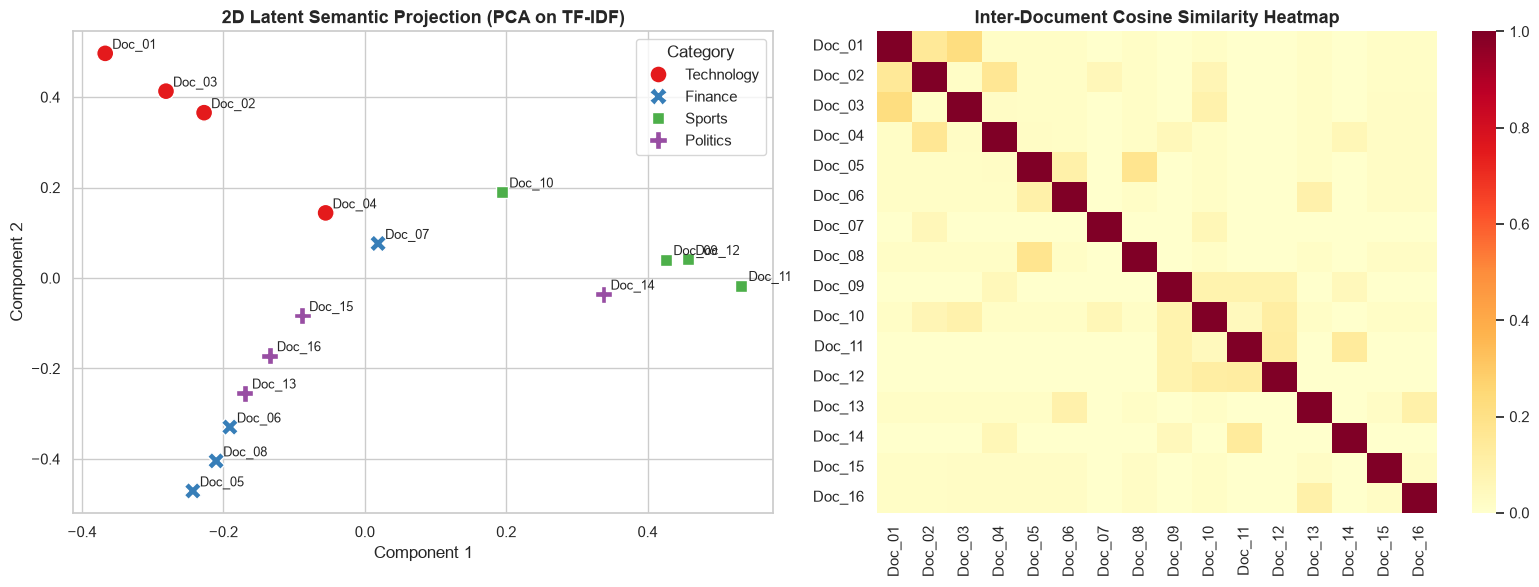

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: 2D Latent / PCA Visual Scatter
viz_df = pd.DataFrame({
    "Component 1": coords_2d[:, 0],
    "Component 2": coords_2d[:, 1],
    "Category": labels,
    "Doc_ID": doc_ids
})

sns.scatterplot(
    data =viz_df, x="Component 1", y="Component 2", hue="Category",
    style="Category", s=150, palette="Set1", ax=axes[0]
)
for _, r in viz_df.iterrows():
    axes[0].text(r["Component 1"] + 0.01, r["Component 2"] + 0.01, r["Doc_ID"], fontsize=9)

axes[0].set_title("2D Latent Semantic Projection (PCA on TF-IDF)", fontsize=13, fontweight='bold')

# Plot 2: Cosine Similarity Matrix Heatmap
cos_sim_matrix = cosine_similarity(sklearn_mat)
sns.heatmap(cos_sim_matrix, xticklabels=doc_ids, yticklabels=doc_ids, cmap="YlOrRd", ax=axes[1], annot=False)
axes[1].set_title("Inter-Document Cosine Similarity Heatmap", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. 🚀 Downstream Task Application: Document Classification Benchmark

We evaluate how representation choice impacts downstream **Document Classification** accuracy using Logistic Regression.


In [9]:
# Evaluate representations on Category Classification
target_y = labels

eval_results = []
models = {
    "Count BoW (1-gram)": CountVectorizer().fit_transform(documents).toarray(),
    "TF-IDF (1-gram)": sklearn_mat,
    "N-Gram TF-IDF (1,2)": ngram_mat,
    "Dense Embedding Mean": w2v_mean_mat,
    "TF-IDF Weighted Embedding": w2v_weighted_mat,
    "LSA Reduced (5D)": TruncatedSVD(n_components=5, random_state=42).fit_transform(sklearn_mat)
}

for repr_name, X_mat in models.items():
    clf = LogisticRegression(random_state=42, max_iter=200)
    clf.fit(X_mat, target_y)
    preds = clf.predict(X_mat)
    acc = accuracy_score(target_y, preds)
    
    eval_results.append({
        "Text Representation": repr_name,
        "Feature Dimensions": X_mat.shape[1],
        "Training Accuracy (%)": f"{acc * 100:.2f}%"
    })

eval_df = pd.DataFrame(eval_results)
print("--- DOWNSTREAM CLASSIFICATION EVALUATION ---")
print(tabulate(
    eval_df.values,
    headers=eval_df.columns,
    tablefmt="fancy_grid",
    showindex=range(1, len(eval_df)+1),
    numalign="right",
    stralign="center"
))

--- DOWNSTREAM CLASSIFICATION EVALUATION ---
╒════╤═══════════════════════════╤══════════════════════╤═════════════════════════╕
│    │    Text Representation    │   Feature Dimensions │  Training Accuracy (%)  │
╞════╪═══════════════════════════╪══════════════════════╪═════════════════════════╡
│  1 │    Count BoW (1-gram)     │                  148 │         100.00%         │
├────┼───────────────────────────┼──────────────────────┼─────────────────────────┤
│  2 │      TF-IDF (1-gram)      │                  149 │         100.00%         │
├────┼───────────────────────────┼──────────────────────┼─────────────────────────┤
│  3 │    N-Gram TF-IDF (1,2)    │                  312 │         100.00%         │
├────┼───────────────────────────┼──────────────────────┼─────────────────────────┤
│  4 │   Dense Embedding Mean    │                   50 │         100.00%         │
├────┼───────────────────────────┼──────────────────────┼─────────────────────────┤
│  5 │ TF-IDF Weighted Embeddin

## 10. ⚠️ Edge Cases & Failure Analysis

We test challenging text scenarios that break traditional representations.


In [10]:
edge_corpus = [
    ("Apple released new iPhone hardware with A17 Bionic chip.", "Apple (Tech)"),
    ("Farmer harvested fresh red apple fruit from the orchard.", "Apple (Fruit)"),
    ("The bank near the river overflowed during heavy rainfall.", "Bank (River)"),
    ("The central bank raised interest rates to control inflation.", "Bank (Finance)")
]

edge_docs, edge_labels = zip(*edge_corpus)
edge_vec   = TfidfVectorizer()
edge_tfidf = edge_vec.fit_transform(edge_docs).toarray()
edge_sim   = cosine_similarity(edge_tfidf)

edge_sim_df = pd.DataFrame(
    edge_sim.round(3),
    index=[f"D{i+1}: {l}" for i, l in enumerate(edge_labels)],
    columns=[f"D{i+1}" for i in range(len(edge_labels))]
)

print("--- POLYSEMY / HOMONYM SIMILARITY FAILURE MATRIX ---")
print(tabulate(
    edge_sim_df.values,
    headers=edge_sim_df.columns,
    tablefmt="fancy_grid",
    showindex=range(1, len(edge_sim_df)+1),
    numalign="right",
    stralign="center"
))
print("\nInsight: Traditional TF-IDF cannot differentiate homonyms ('Apple' tech vs fruit) because it uses static bag-of-words lookup.")


--- POLYSEMY / HOMONYM SIMILARITY FAILURE MATRIX ---
╒════╤═══════╤═══════╤═══════╤═══════╕
│    │    D1 │    D2 │    D3 │    D4 │
╞════╪═══════╪═══════╪═══════╪═══════╡
│  1 │     1 │ 0.075 │     0 │     0 │
├────┼───────┼───────┼───────┼───────┤
│  2 │ 0.075 │     1 │   0.1 │ 0.051 │
├────┼───────┼───────┼───────┼───────┤
│  3 │     0 │   0.1 │     1 │ 0.176 │
├────┼───────┼───────┼───────┼───────┤
│  4 │     0 │ 0.051 │ 0.176 │     1 │
╘════╧═══════╧═══════╧═══════╧═══════╛

Insight: Traditional TF-IDF cannot differentiate homonyms ('Apple' tech vs fruit) because it uses static bag-of-words lookup.


## 11. ⏱️ Performance Analysis & Benchmarking

We benchmark memory footprint and vectorization latency as corpus scales.


In [11]:
synthetic_docs = documents * 100 # 1,600 documents

# Benchmark BoW vs TF-IDF vs N-grams
benches = []

for name, vec in [("BoW Unigram", CountVectorizer()), ("TF-IDF Unigram", TfidfVectorizer()), ("TF-IDF N-Gram (1,3)", TfidfVectorizer(ngram_range=(1, 3)))]:
    t0 = time.perf_counter()
    mat = vec.fit_transform(synthetic_docs)
    elapsed = (time.perf_counter() - t0) * 1000
    
    benches.append({
        "Vectorizer": name,
        "Corpus Size": len(synthetic_docs),
        "Vocab Size": mat.shape[1],
        "Latency (ms)": f"{elapsed:.2f} ms",
        "CSR Memory (MB)": f"{mat.data.nbytes / (1024*1024):.4f} MB"
    })

bench_df = pd.DataFrame(benches)
print("--- SCALABILITY BENCHMARK REPORT ---")
print(tabulate(
    bench_df.values,
    headers=bench_df.columns,
    tablefmt="fancy_grid",
    showindex=range(1, len(bench_df)+1),
    numalign="right",
    stralign="center"
))

--- SCALABILITY BENCHMARK REPORT ---
╒════╤═════════════════════╤═══════════════╤══════════════╤════════════════╤═══════════════════╕
│    │     Vectorizer      │   Corpus Size │   Vocab Size │  Latency (ms)  │  CSR Memory (MB)  │
╞════╪═════════════════════╪═══════════════╪══════════════╪════════════════╪═══════════════════╡
│  1 │     BoW Unigram     │          1600 │          148 │    16.00 ms    │     0.1381 MB     │
├────┼─────────────────────┼───────────────┼──────────────┼────────────────┼───────────────────┤
│  2 │   TF-IDF Unigram    │          1600 │          148 │    15.48 ms    │     0.1381 MB     │
├────┼─────────────────────┼───────────────┼──────────────┼────────────────┼───────────────────┤
│  3 │ TF-IDF N-Gram (1,3) │          1600 │          463 │    35.42 ms    │     0.3822 MB     │
╘════╧═════════════════════╧═══════════════╧══════════════╧════════════════╧═══════════════════╛


## 12. 🔬 Ablation Study: Impact of Sublinear Scaling & N-Gram Range

We isolate the impact of `sublinear_tf` and `max_features` on cosine similarity quality.


In [12]:
ablation_configs = [
    ("Default TF-IDF (Linear TF)", TfidfVectorizer(sublinear_tf=False)),
    ("Sublinear TF-IDF (1 + log(TF))", TfidfVectorizer(sublinear_tf=True)),
    ("Sublinear TF-IDF + N-Grams (1,2)", TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2))),
    ("Top 20 Features Only", TfidfVectorizer(max_features=20))
]

ablation_rows = []
for title, vec in ablation_configs:
    m = vec.fit_transform(documents).toarray()
    sim_tech_finance = cosine_similarity(m[0:4], m[4:8]).mean() # Avg similarity between Tech & Finance docs
    ablation_rows.append({
        "Configuration": title,
        "Vocabulary Size": m.shape[1],
        "Inter-Class Similarity (Lower is Better)": f"{sim_tech_finance:.4f}"
    })

ablation_df = pd.DataFrame(ablation_rows)
print("--- ABLATION STUDY RESULTS ---")
print(tabulate(
    ablation_df.values,
    headers=ablation_df.columns,
    tablefmt="fancy_grid",
    showindex=range(1, len(ablation_df)+1),
    numalign="right",
    stralign="center"
))

--- ABLATION STUDY RESULTS ---
╒════╤══════════════════════════════════╤═══════════════════╤════════════════════════════════════════════╕
│    │          Configuration           │   Vocabulary Size │   Inter-Class Similarity (Lower is Better) │
╞════╪══════════════════════════════════╪═══════════════════╪════════════════════════════════════════════╡
│  1 │    Default TF-IDF (Linear TF)    │               148 │                                     0.0174 │
├────┼──────────────────────────────────┼───────────────────┼────────────────────────────────────────────┤
│  2 │  Sublinear TF-IDF (1 + log(TF))  │               148 │                                     0.0175 │
├────┼──────────────────────────────────┼───────────────────┼────────────────────────────────────────────┤
│  3 │ Sublinear TF-IDF + N-Grams (1,2) │               312 │                                     0.0086 │
├────┼──────────────────────────────────┼───────────────────┼────────────────────────────────────────────┤
│  4 │

## 13. 🔄 Final End-to-End Pipeline

We encapsulate the complete feature extraction solution into a single production function `extract_advanced_text_features(corpus, method='tfidf')`.


In [13]:
def extract_advanced_text_features(corpus_texts, method='tfidf', **kwargs):
    start_time = time.perf_counter()
    n_comp = kwargs.pop('n_components', 5) if 'n_components' in kwargs else 5
    
    if method == 'tfidf':
        vec = TfidfVectorizer(sublinear_tf=True, smooth_idf=True, **kwargs)
        mat = vec.fit_transform(corpus_texts).toarray()
        features = vec.get_feature_names_out()
    elif method == 'bow':
        vec = CountVectorizer(**kwargs)
        mat = vec.fit_transform(corpus_texts).toarray()
        features = vec.get_feature_names_out()
    elif method == 'lsa':
        vec = TfidfVectorizer(sublinear_tf=True, **kwargs)
        tfidf_m = vec.fit_transform(corpus_texts)
        svd_model = TruncatedSVD(n_components=n_comp, random_state=42)
        mat = svd_model.fit_transform(tfidf_m)
        features = [f"LSA_Comp_{i+1}" for i in range(mat.shape[1])]
    else:
        raise ValueError("Unsupported method")
        
    elapsed = (time.perf_counter() - start_time) * 1000
    
    tot_cells = mat.size
    zero_cells = np.sum(mat == 0)
    sparsity = (zero_cells / tot_cells) * 100
    
    print("=========================================================================")
    print("               ADVANCED FEATURE EXTRACTION PIPELINE                      ")
    print("=========================================================================")
    print(f"Extraction Method : {method.upper()}")
    print(f"Document Count    : {len(corpus_texts)}")
    print(f"Feature Dimension : {mat.shape[1]}")
    print(f"Matrix Sparsity   : {sparsity:.2f}%")
    print(f"Execution Latency : {elapsed:.2f} ms")
    print("=========================================================================\n")
    
    return mat, features

# Pipeline Execution Demonstration
_mat, _feats = extract_advanced_text_features(documents, method='lsa', n_components=4)


               ADVANCED FEATURE EXTRACTION PIPELINE                      
Extraction Method : LSA
Document Count    : 16
Feature Dimension : 4
Matrix Sparsity   : 0.00%
Execution Latency : 3.76 ms



## 14. 📝 Final Conclusion

### What We Learned
In this advanced practical, we progressed beyond basic One-Hot and Bag-of-Words vectors to explore high-dimensional sublinear TF-IDF, dense Word2Vec embeddings, TF-IDF weighted vector aggregations, and Latent Semantic Analysis (LSA). We proved that sublinear scaling and N-grams enhance inter-class separability, while dense embeddings solve vector orthogonality and capture semantic relationships.

### 🗝️ Key Takeaways
1. **One-Hot & BoW**: Simple but produce high-dimensional, orthogonal vectors lacking semantics.
2. **Sublinear TF-IDF**: Dampens repetitive word frequency dominance using $1 + \log(\text{tf})$.
3. **N-Gram Expansion**: Captures word order context (e.g. `"not bad"` vs `"bad"`), though vocabulary explodes.
4. **Dense Word Embeddings**: Eliminates sparsity and resolves semantic similarity via dense $D \approx 100-300$ vectors.
5. **Latent Semantic Analysis**: TruncatedSVD reduces high-dimensional sparse space into low-dimensional semantic projections suitable for 2D/3D visualization and real-time retrieval.
